8.	Applying SVM, Naive Bayes, Decision tree and KNN predict diabetes based on features set. Compare the four classification algorithms with performance metrics such as accuracy, recall, precision, F1- score. Also design the heat map confusion matrix for above algorithms and construct ROC curve for comparison.

Dataset: pima-indians-diabetes.data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, roc_curve, auc
)


In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "ROC Curve": roc_curve(y_test, y_prob),
        "AUC": auc(*roc_curve(y_test, y_prob)[:2])
    }

In [ ]:
for name, metrics in results.items():
    print(f"\nModel: {name}")
    for key, value in metrics.items():
        if isinstance(value, (float, int)):
            print(f"{key}: {value:.3f}")
        elif key == "Confusion Matrix":
            print(f"{key}:\n{value}")


Model: SVM
Accuracy: 0.786
Recall: 0.632
Precision: 0.750
F1-Score: 0.686
Confusion Matrix:
[[85 12]
 [21 36]]
AUC: 0.858

Model: Naive Bayes
Accuracy: 0.747
Recall: 0.579
Precision: 0.688
F1-Score: 0.629
Confusion Matrix:
[[82 15]
 [24 33]]
AUC: 0.809

Model: Decision Tree
Accuracy: 0.682
Recall: 0.596
Precision: 0.567
F1-Score: 0.581
Confusion Matrix:
[[71 26]
 [23 34]]
AUC: 0.664

Model: KNN
Accuracy: 0.727
Recall: 0.544
Precision: 0.660
F1-Score: 0.596
Confusion Matrix:
[[81 16]
 [26 31]]
AUC: 0.800


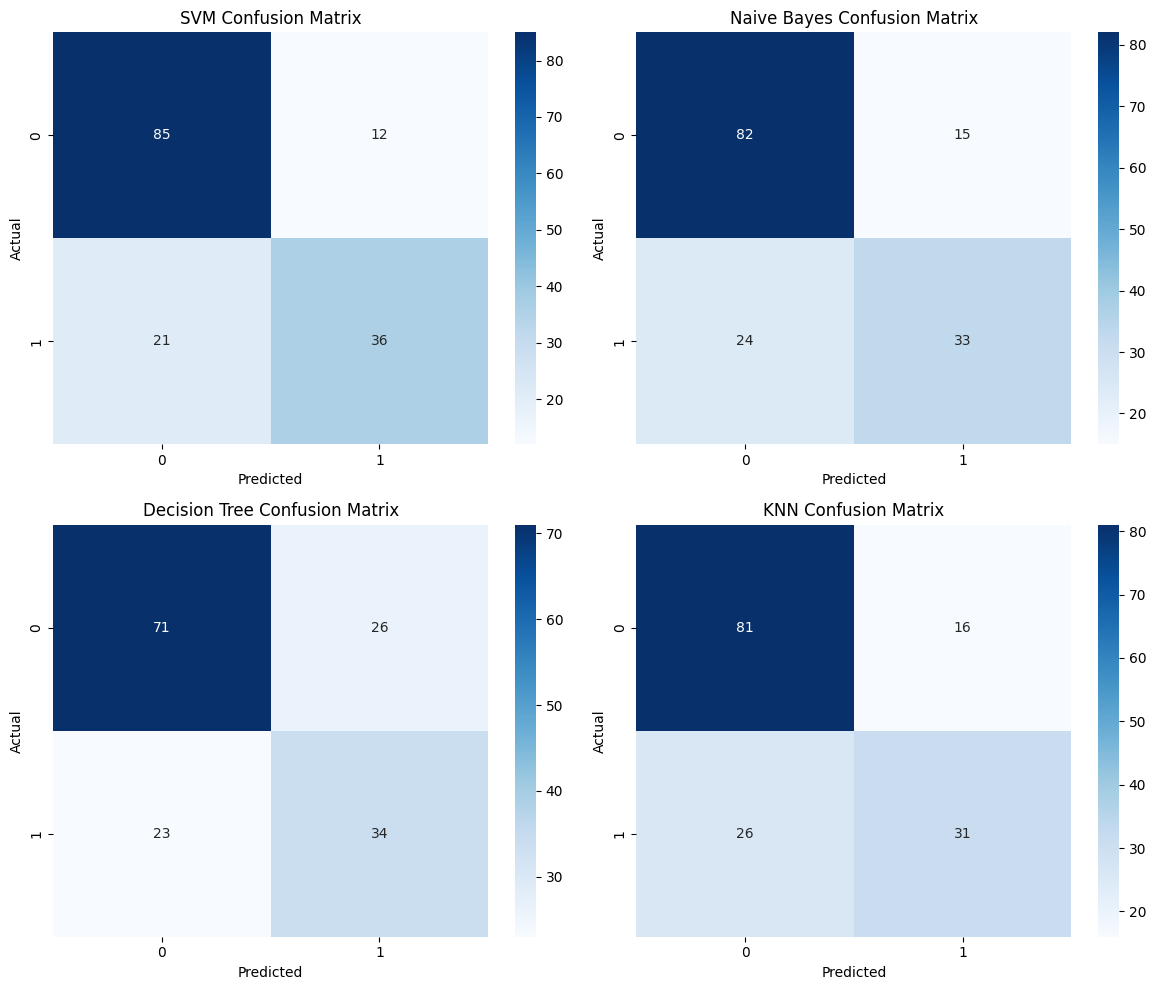

In [ ]:
plt.figure(figsize=(12, 10))
for i, (name, metrics) in enumerate(results.items(), 1):
    plt.subplot(2, 2, i)
    sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

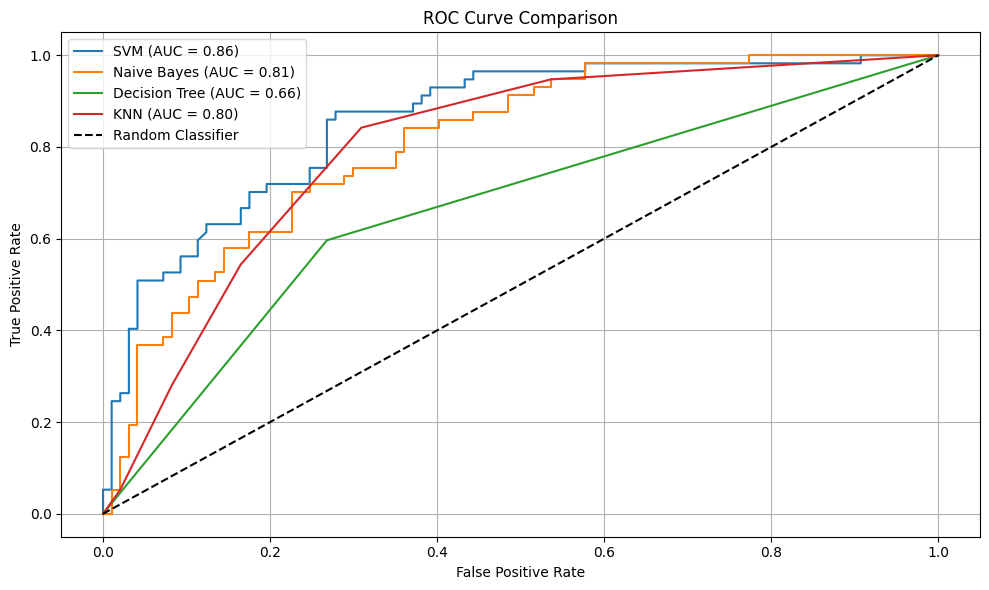

In [ ]:
plt.figure(figsize=(10, 6))
for name, metrics in results.items():
    fpr, tpr = metrics["ROC Curve"][:2]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()